In [8]:
!which python

/bin/python


In [9]:
! echo $PATH

/bin:/mnt/home/tersenov/.vscode-server/cli/servers/Stable-17baf841131aa23349f217ca7c570c76ee87b957/server/bin/remote-cli:/home/tersenov/.local/bin:/usr/local/cuda-12.4/bin:/home/tersenov/anaconda3/bin:/home/tersenov/anaconda3/condabin:/home/tersenov/.local/bin:/usr/lib/perfsonar/scripts:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/usr/games:/usr/local/games:/snap/bin:/mnt/home/tersenov/.vscode-server/cli/servers/Stable-17baf841131aa23349f217ca7c570c76ee87b957/server/bin/remote-cli:/home/tersenov/.local/bin:/usr/local/cuda-12.4/bin:/home/tersenov/anaconda3/bin:/home/tersenov/anaconda3/condabin:/home/tersenov/.local/bin:/usr/lib/perfsonar/scripts:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/usr/games:/usr/local/games:/snap/bin


In [10]:
!python --version

Python 3.10.12


In [11]:
import pycs
import multiprocessing as mp

In [12]:
import h5py
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt

In [13]:
from pycs.sparsity.mrs.mrs_tools import *

## Add noise to the map

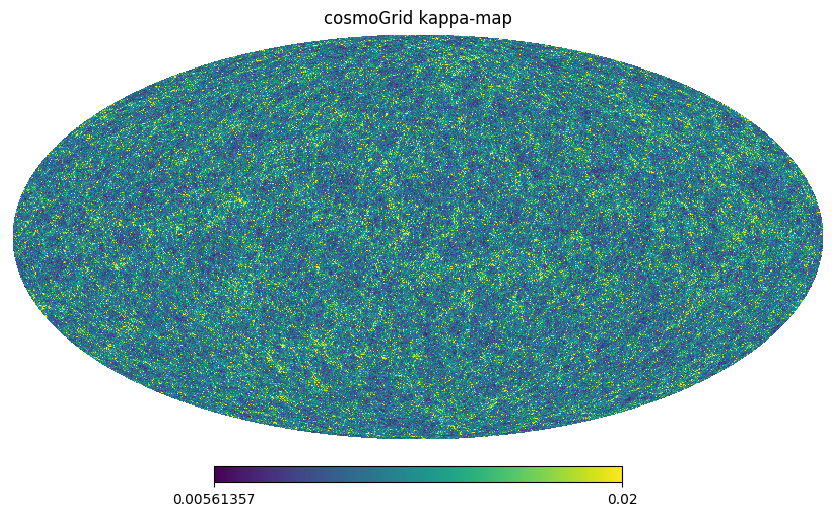

In [7]:
with h5py.File('/home/tersenov/CosmoGridV1/stage3_forecast/new_grid/cosmo_000002/perm_0000/projected_probes_maps_nobaryons512.h5', 'r') as f:
    kg = np.array(f['kg/stage3_lensing1'])
# Display the image.
inmap = kg
hp.mollview(inmap,max=0.02, title='cosmoGrid kappa-map')

In [7]:
def add_shape_noise(kg, sigma_e=0.26, galaxy_density=6.75, nside=512):
    """
    Adds shape noise to a full-sky Healpix convergence (kappa) map.

    Parameters:
    - kg: np.ndarray, the input kappa map
    - sigma_e: float, intrinsic ellipticity dispersion per galaxy
    - galaxy_density: float, galaxy number density per arcmin²
    - nside: int, Healpix resolution parameter

    Returns:
    - noisy_kg: np.ndarray, kappa map with added shape noise
    """
    npix = hp.nside2npix(nside)  # Total number of pixels
    pixel_area_arcmin2 = hp.nside2pixarea(nside, degrees=True) * 3600  # Convert to arcmin²
    # print(f"Pixel area: {pixel_area_arcmin2:.2f} arcmin²")  # Print pixel area for reference
    sigma_pix = sigma_e / np.sqrt(galaxy_density * pixel_area_arcmin2)  # Compute pixel noise
    # print(f"Pixel noise: {sigma_pix:.3f} kappa")  # Print pixel noise for reference

    noise = np.random.normal(loc=0, scale=sigma_pix, size=npix)  # Generate noise
    return kg + noise  # Add noise to kappa map

In [ ]:
kg_noisy = add_shape_noise(kg)
hp.mollview(kg_noisy,max=0.08, title='cosmoGrid kappa-map')

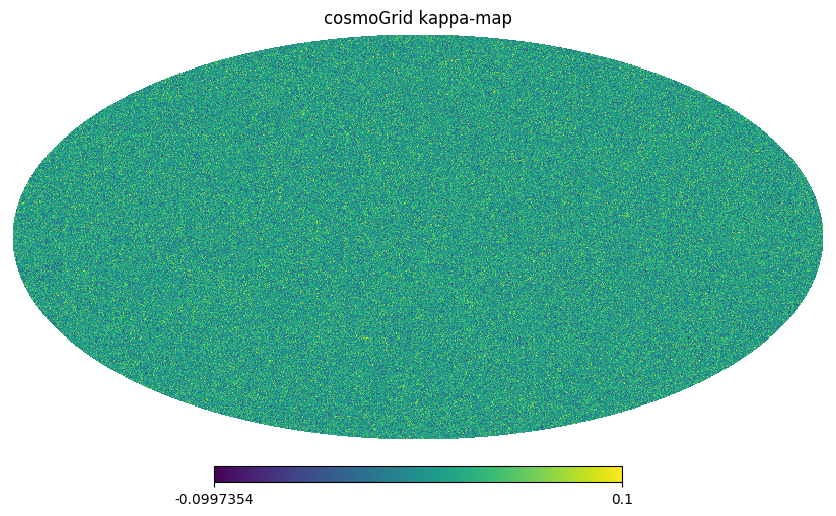

In [15]:
# Generate Gaussian noise (white noise)
rng = np.random.default_rng(42)  # Use a seed for reproducibility if needed
noise = rng.normal(loc=0, scale=0.024, size=kg.shape)
kg_noisy = kg + noise  # Add noise to the kappa map
hp.mollview(kg_noisy,max=0.1, title='cosmoGrid kappa-map')

setting the output map dtype to [dtype('float64')]


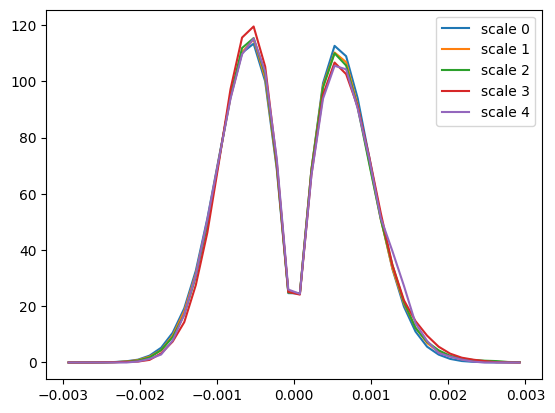

In [21]:
bins_ener, l1norm_ener = get_norm_wtl1_sphere(kg_noisy, nscales=5, nbins=None, Mask=None, min_snr=-0.003, max_snr=0.003, path="/home/tersenov/software/bar_impact/temp_dir")

for i in range(5):
    plt.plot(bins_ener[i], l1norm_ener[i], label=f'scale {i}')
plt.legend()    

## Wavelet transform on the sphere

In [15]:
with h5py.File('/home/tersenov/CosmoGridV1/stage3_forecast/new_grid/cosmo_000002/perm_0000/projected_probes_maps_nobaryons512.h5', 'r') as f:
    kg = np.array(f['kg/stage3_lensing1'])

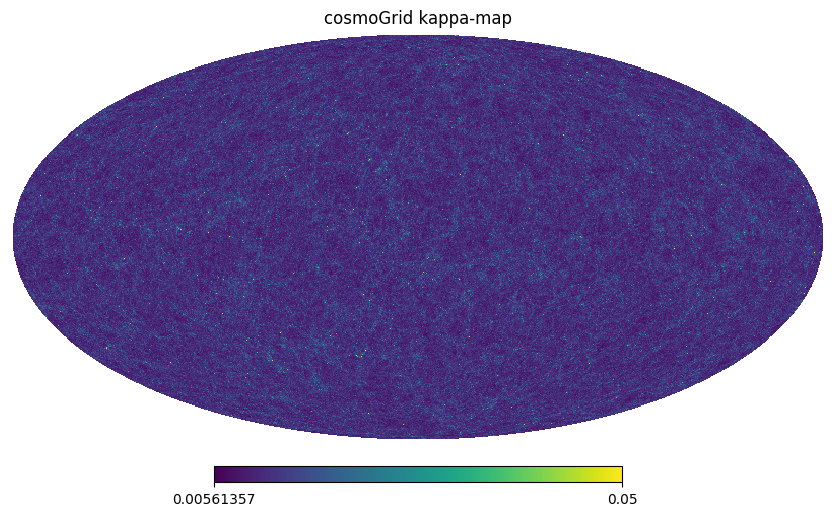

In [16]:
# Display the image.
inmap = kg
hp.mollview(inmap,max=0.05, title='cosmoGrid kappa-map')

In [18]:
from pycs.sparsity.mrs.mrs_starlet import mrs_uwttrans

In [20]:
w = mrs_uwttrans(inmap, nscale=8, verbose=False) # w = compute the wavelet transform of the map

In [21]:
w.shape

(8, 3145728)

In [ ]:
w.shape
for filter_ in range(w.shape[0]):
    fig = plt.figure(filter_)
    hp.mollview(w[filter_, :], title=f'Wavelet {filter_}')
    plt.show()

# noiseless 

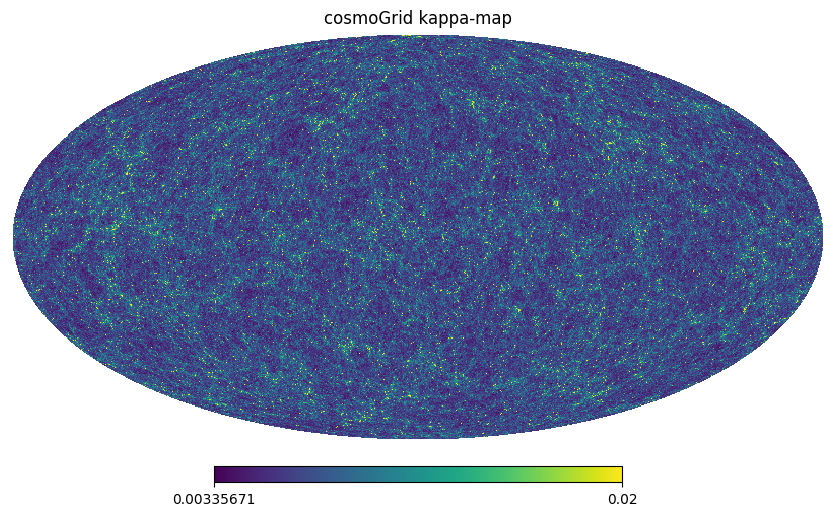

In [23]:
with h5py.File('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/perm_0000/projected_probes_maps_baryonified512.h5', 'r') as f:
    kg = np.array(f['kg/stage3_lensing1'])
# Display the image.
inmap = kg
hp.mollview(inmap,max=0.02, title='cosmoGrid kappa-map')

In [ ]:
bins_ener, l1norm_ener = get_norm_wtl1_sphere(kg, nscales=5, nbins=None, Mask=None, min_snr=-0.003, max_snr=0.003, path="/home/tersenov/software/bar_impact/temp_dir")

for i in range(5):
    plt.plot(bins_ener[i], l1norm_ener[i], label=f'scale {i}')
plt.legend()    

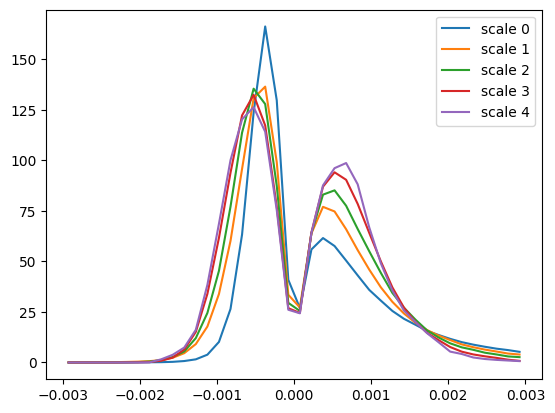

In [27]:
bins_ener, l1norm_ener = get_norm_wtl1_sphere(kg, nscales=8, nbins=None, Mask=None, min_snr=-0.003, max_snr=0.003, path="/home/tersenov/software/bar_impact/temp_dir")

for i in range(5):
    plt.plot(bins_ener[i], l1norm_ener[i], label=f'scale {i}')
plt.legend()    

## Normalized $\ell_1$-norm on the sphere

In [25]:
def get_norm_wtl1_sphere(Map, nscales, nbins=None, Mask=None, min_snr=None, max_snr=None, path="/."):

    # Set default for nbins if not provided
    if nbins is None:
        nbins = 40

    # Perform undecimated wavelet transform on the spherical map
    WT = mrs_uwttrans(Map, nscale=nscales, verbose=False, path=path)

    # Initialize lists to collect the l1 norm and bins
    l1norm_coll = []
    bins_coll = []

      # Loop through each scale of the wavelet transform
    for i in range(nscales):
        ScaleCoeffs = WT[i]  # Accessing the coefficients for the i-th scale

        # Apply the mask if provided
        if Mask is not None:
            ScaleCoeffs = ScaleCoeffs[Mask != 0]

        # Normalize the wavelet scale to the same energy level
        energy = np.sum(ScaleCoeffs**2)
        normalization_factor = np.sqrt(energy)
        if normalization_factor > 0:
            ScaleCoeffs_normalized = ScaleCoeffs / normalization_factor 
        
        # Set the minimum and maximum values based on inputs or defaults
        min_val = min_snr if min_snr is not None else np.min(ScaleCoeffs_normalized)
        max_val = max_snr if max_snr is not None else np.max(ScaleCoeffs_normalized)

        # Define thresholds and bins
        thresholds = np.linspace(min_val, max_val, nbins + 1)
        bins = 0.5 * (thresholds[:-1] + thresholds[1:])

        # Digitize the values into bins
        digitized = np.digitize(ScaleCoeffs_normalized, thresholds)

        # Calculate the l1 norm for each bin
        bin_l1_norm = [
            np.sum(np.abs(ScaleCoeffs_normalized[digitized == j]))
            for j in range(1, len(thresholds))
        ]

        # Store the bins and l1 norms for this scale
        bins_coll.append(bins)
        l1norm_coll.append(bin_l1_norm)

    # Return the bins and l1 norms for each scale
    return np.array(bins_coll), np.array(l1norm_coll)

Example usage:

setting the output map dtype to [dtype('<f4')]


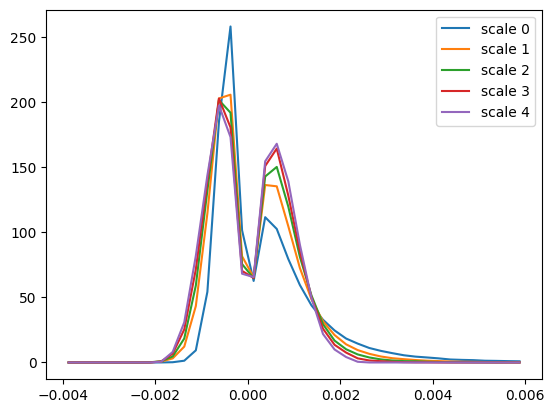

In [18]:
bins_ener, l1norm_ener = get_norm_wtl1_sphere(kg, nscales=5, nbins=None, Mask=None, min_snr=-0.004, max_snr=0.006, path="/home/tersenov/software/bar_impact/temp_dir")

for i in range(5):
    plt.plot(bins_ener[i], l1norm_ener[i], label=f'scale {i}')
plt.legend()    

Example on a different cosmology map:

In [24]:
with h5py.File('/home/tersenov/CosmoGridV1/stage3_forecast/grid/cosmo_002079/perm_0000/projected_probes_maps_nobaryons512.h5', 'r') as f:
    kg = np.array(f['kg/stage3_lensing1'])
# Display the image.
inmap = kg
hp.mollview(inmap,max=0.05, title='cosmoGrid kappa-map')

In [26]:
bins_ener, l1norm_ener = get_norm_wtl1_sphere(kg, nscales=5, nbins=None, Mask=None, min_snr=-0.004, max_snr=0.006)
for i in range(5):
    plt.plot(bins_ener[i], l1norm_ener[i], label=f'scale {i}')
plt.legend()    

setting the output map dtype to [dtype('<f4')]


# Run on all cosmologies

In [9]:
import os
import re

In [9]:
base_dir = "/home/tersenov/CosmoGridV1/stage3_forecast/grid/"

filename = "projected_probes_maps_baryonified512.h5"  # File of interest
perm_dirs = [f"perm_{i:04d}" for i in range(7)]  # "perm_0000" to "perm_0006"

# Find all directories matching "cosmo_XXXXX"
# cosmo_dirs = sorted([d for d in os.listdir(base_dir) if re.match(r"cosmo_\d{6}", d)])
cosmo_dirs = sorted([d for d in os.listdir(base_dir) if d.startswith("cosmo_")])

In [25]:
np.array(cosmo_dirs).shape, perm_dirs

((2502,),
 ['perm_0000',
  'perm_0001',
  'perm_0002',
  'perm_0003',
  'perm_0004',
  'perm_0005',
  'perm_0006'])

In [10]:
import tempfile
# Function to compute L1-norms for a given file
def process_file(file_path):
    """Loads the file, extracts the kappa map, computes L1 norms, and saves results."""
    try:
        with h5py.File(file_path, "r") as f:
            kg = np.array(f["kg/stage3_lensing1"])  # Extract kappa map
        
        # # Generate Gaussian noise
        # rng = np.random.default_rng()  # No fixed seed → different noise every run
        # noise = rng.normal(loc=0, scale=0.024, size=kg.shape)
        # kg_noisy = kg + noise  # Add noise to the kappa map
        
        # Add shape noise
        kg_noisy = add_shape_noise(kg, sigma_e=0.26, galaxy_density=6.75, nside=512)

        
        # Create a unique temporary directory per process
        with tempfile.TemporaryDirectory() as tmp_dir:
            # Compute L1 norms using a unique temp path
            bins, l1norms = get_norm_wtl1_sphere(
                kg_noisy, nscales=5, nbins=40, Mask=None, min_snr=-0.003, max_snr=0.003,
                path=tmp_dir  # <-- Ensures unique temp files
            )
            
        # Save results
        save_path = file_path.replace(".h5", "_l1_norms_bin1_noisy_s026.npy")  # Change extension
        np.save(save_path, l1norms)
        
        print(f"Processed: {file_path} -> {save_path}")
        return save_path  # For debugging/logging
    
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None


same, but checking if file already exists

In [12]:
import os
def process_file(file_path):
    """Loads the file, extracts the kappa map, computes L1 norms, and saves results."""
    
    # Define the expected output filename
    save_path = file_path.replace(".h5", "_l1_norms_bin1.npy")

    # Check if the file already exists; if so, skip processing
    if os.path.exists(save_path):
        print(f"Skipping {file_path}, L1 norm file already exists.")
        return save_path  # Return the path to indicate it was "processed"

    try:
        with h5py.File(file_path, "r") as f:
            kg = np.array(f["kg/stage3_lensing1"])  # Extract kappa map

        # Create a unique temporary directory per process
        with tempfile.TemporaryDirectory() as tmp_dir:
            # Compute L1 norms using a unique temp path
            bins, l1norms = get_norm_wtl1_sphere(
                kg, nscales=5, nbins=40, Mask=None, min_snr=-0.004, max_snr=0.006,
                path=tmp_dir  # <-- Ensures unique temp files
            )

        # Save results
        np.save(save_path, l1norms)
        
        print(f"Processed: {file_path} -> {save_path}")
        return save_path
    
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None


In [13]:
process_file('/home/tersenov/CosmoGridV1/stage3_forecast/grid/cosmo_003031/perm_0000/projected_probes_maps_baryonified512.h5')

Skipping /home/tersenov/CosmoGridV1/stage3_forecast/grid/cosmo_003031/perm_0000/projected_probes_maps_baryonified512.h5, L1 norm file already exists.


'/home/tersenov/CosmoGridV1/stage3_forecast/grid/cosmo_003031/perm_0000/projected_probes_maps_baryonified512_l1_norms_bin1.npy'

In [29]:
cosmo_dirs_short = cosmo_dirs[:10]  # For testing

In [14]:
# Generate all file paths
file_paths = [
    os.path.join(base_dir, cosmo, perm, filename)
    for cosmo in cosmo_dirs
    for perm in perm_dirs
]

In [15]:
mp.cpu_count()

128

In [16]:
len(file_paths)

17514

In [17]:
# Use multiprocessing to process files in parallel
num_workers = min(mp.cpu_count()/2, len(file_paths))  # Use all CPUs, but not more than needed

In [18]:
num_workers

64.0

In [ ]:
if __name__ == "__main__":
    with mp.Pool(processes=80) as pool:
        results = pool.map(process_file, file_paths)  # Run in parallel

Skipping /home/tersenov/CosmoGridV1/stage3_forecast/grid/cosmo_000012/perm_0006/projected_probes_maps_baryonified512.h5, L1 norm file already exists.Skipping /home/tersenov/CosmoGridV1/stage3_forecast/grid/cosmo_000001/perm_0000/projected_probes_maps_baryonified512.h5, L1 norm file already exists.Skipping /home/tersenov/CosmoGridV1/stage3_forecast/grid/cosmo_000084/perm_0003/projected_probes_maps_baryonified512.h5, L1 norm file already exists.Skipping /home/tersenov/CosmoGridV1/stage3_forecast/grid/cosmo_000150/perm_0006/projected_probes_maps_baryonified512.h5, L1 norm file already exists.Skipping /home/tersenov/CosmoGridV1/stage3_forecast/grid/cosmo_000134/perm_0000/projected_probes_maps_baryonified512.h5, L1 norm file already exists.

Skipping /home/tersenov/CosmoGridV1/stage3_forecast/grid/cosmo_000062/perm_0004/projected_probes_maps_baryonified512.h5, L1 norm file already exists.Skipping /home/tersenov/CosmoGridV1/stage3_forecast/grid/cosmo_000014/perm_0000/projected_probes_maps_ba

In [51]:
l1_0000_bin1_nobar = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/grid/cosmo_000002/perm_0006/projected_probes_maps_nobaryons512_l1_norms.npy', allow_pickle=True)  
# l1_0000_bin2 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/grid/cosmo_000011/perm_0006/projected_probes_maps_nobaryons512_l1_norms_bin2.npy', allow_pickle=True) 
# l1_0000_bin3 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/grid/cosmo_000011/perm_0006/projected_probes_maps_nobaryons512_l1_norms_bin3.npy', allow_pickle=True) 
# l1_0000_bin4 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/grid/cosmo_000011/perm_0006/projected_probes_maps_nobaryons512_l1_norms_bin4.npy', allow_pickle=True) 
l1_0000_bin1_bar = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/grid/cosmo_000002/perm_0006/projected_probes_maps_baryonified512_l1_norms_bin1.npy', allow_pickle=True)  

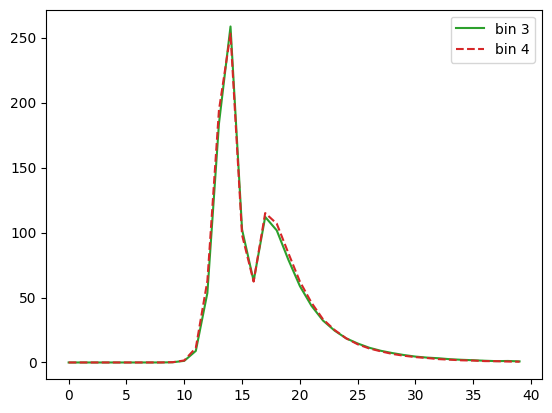

In [52]:
for i in range(0,1):
    # plt.plot(l1_0006_bin1[i], label=f'bin 1', color='C0')
    # plt.plot(l1_0006_bin2[i], label=f'bin 2', color='C1')
    plt.plot(l1_0000_bin1_nobar[i], label=f'bin 3', color='C2')
    plt.plot(l1_0000_bin1_bar[i], label=f'bin 4', color='C3', linestyle='--')
plt.legend()    

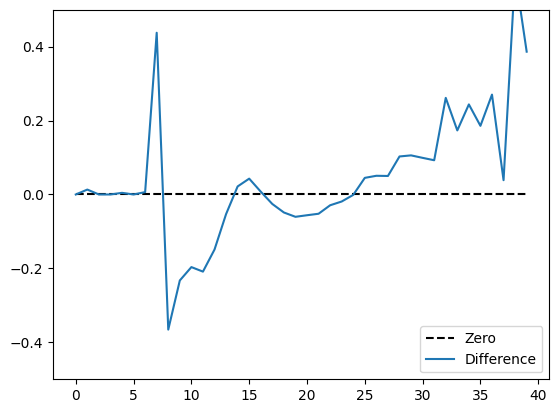

In [59]:
plt.plot(np.arange(l1_0000_bin1_nobar[0].shape[0]), np.zeros_like(l1_0000_bin1_nobar[0]), label='Zero', color='black', linestyle='--')
plt.plot((l1_0000_bin1_nobar[0]-l1_0000_bin1_bar[0])/(l1_0000_bin1_bar[0] + 1e-3), label='Difference')
plt.ylim(-0.5, 0.5)
plt.legend()    

### Alternative way to handle the temp directory

In [77]:
# Global temp directory (define once)
TMP_DIR = "/tmp/mrs_temp/"  # Use a fast local disk if possible
os.makedirs(TMP_DIR, exist_ok=True)  # Create it once

def process_file(file_path):
    """Loads the file, extracts the kappa map, computes L1 norms, and saves results."""
    try:
        with h5py.File(file_path, "r") as f:
            kg = np.array(f["kg/stage3_lensing1"])  # Extract kappa map

        # Generate a unique filename inside TMP_DIR
        unique_path = os.path.join(TMP_DIR, f"proc_{os.getpid()}_{os.path.basename(file_path)}")

        # Compute L1 norms using a shared temp directory but unique filenames
        bins, l1norms = get_norm_wtl1_sphere(
            kg, nscales=5, nbins=40, Mask=None, min_snr=-0.004, max_snr=0.006,
            path=unique_path  # Ensure unique files per process
        )

        # Save results
        save_path = file_path.replace(".h5", "_l1_norms.npy")
        np.save(save_path, l1norms)
        
        print(f"Processed: {file_path} -> {save_path}")
        return save_path
    
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None


In [78]:
process_file('/home/tersenov/CosmoGridV1/stage3_forecast/grid/cosmo_003031/perm_0000/projected_probes_maps_nobaryons512.h5')

setting the output map dtype to [dtype('<f4')]


Processed: /home/tersenov/CosmoGridV1/stage3_forecast/grid/cosmo_003031/perm_0000/projected_probes_maps_nobaryons512.h5 -> /home/tersenov/CosmoGridV1/stage3_forecast/grid/cosmo_003031/perm_0000/projected_probes_maps_nobaryons512_l1_norms.npy


'/home/tersenov/CosmoGridV1/stage3_forecast/grid/cosmo_003031/perm_0000/projected_probes_maps_nobaryons512_l1_norms.npy'

In [ ]:
if __name__ == "__main__":
    with mp.Pool(processes=70) as pool:
        results = pool.map(process_file, file_paths)  # Run in parallel

# Fiducial

In [11]:
base_dir = "/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/"

filename = "projected_probes_maps_baryonified512.h5"  # File of interest
perm_dirs = [f"perm_{i:04d}" for i in range(200)]  # "perm_0000" to "perm_0006"

# Find all directories matching "cosmo_XXXXX"
# cosmo_dirs = sorted([d for d in os.listdir(base_dir) if re.match(r"cosmo_\d{6}", d)])
# cosmo_dirs = sorted([d for d in os.listdir(base_dir) if d.startswith("cosmo_")])

In [12]:
# Generate all file paths
file_paths = [
    os.path.join(base_dir, perm, filename)
    for perm in perm_dirs
]

In [13]:
np.array(file_paths).shape

(200,)

In [14]:
if __name__ == "__main__":
    with mp.Pool(processes=70) as pool:
        results = pool.map(process_file, file_paths)  # Run in parallel

setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to

Processed: /home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/perm_0004/projected_probes_maps_baryonified512.h5 -> /home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/perm_0004/projected_probes_maps_baryonified512_l1_norms_bin1_noisy_s026.npy


setting the output map dtype to [dtype('float64')]


Processed: /home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/perm_0002/projected_probes_maps_baryonified512.h5 -> /home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/perm_0002/projected_probes_maps_baryonified512_l1_norms_bin1_noisy_s026.npy
Processed: /home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/perm_0027/projected_probes_maps_baryonified512.h5 -> /home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/perm_0027/projected_probes_maps_baryonified512_l1_norms_bin1_noisy_s026.npy


setting the output map dtype to [dtype('float64')]


...

Processed: /home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/perm_0095/projected_probes_maps_baryonified512.h5 -> /home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/perm_0095/projected_probes_maps_baryonified512_l1_norms_bin1_noisy_s026.npy


setting the output map dtype to [dtype('float64')]


Processed: /home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/perm_0141/projected_probes_maps_baryonified512.h5 -> /home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/perm_0141/projected_probes_maps_baryonified512_l1_norms_bin1_noisy_s026.npy
Processed: /home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/perm_0138/projected_probes_maps_baryonified512.h5 -> /home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/perm_0138/projected_probes_maps_baryonified512_l1_norms_bin1_noisy_s026.npy


setting the output map dtype to [dtype('float64')]


Processed: /home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/perm_0147/projected_probes_maps_baryonified512.h5 -> /home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/perm_0147/projected_probes_maps_baryonified512_l1_norms_bin1_noisy_s026.npy
Processed: /home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/perm_0134/projected_probes_maps_baryonified512.h5 -> /home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/perm_0134/projected_probes_maps_baryonified512_l1_norms_bin1_noisy_s026.npy
Processed: /home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/perm_0140/projected_probes_maps_baryonified512.h5 -> /home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/perm_0140/projected_probes_maps_baryonified512_l1_norms_bin1_noisy_s026.npy
Processed: /home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/perm_0130/projected_probes_maps_baryonified512.h5 -> /home/tersenov/CosmoGridV1/stage3_forecast/fidu